# 📞 Case Study 2 — Bharath Mobile: Reducing Customer Churn

**SDNB Vaishnav College for Women — Business Analytics Capstone**

---

## 🏢 Background

You have joined **Bharath Mobile**, a fast-growing Indian telecom operator, as their first **Customer Analytics Intern**.

The Head of Retention, Ms. Latha Krishnan, has a pressing problem:

> *"We're losing customers faster than we can acquire them. I have a suspicion who's at risk, but I need data to back it up. Build me a profile of who churns — and tell me which 100 customers we should call this month before we lose them."*

You have a snapshot of **500 active customers** with their tenure, plan, billing, usage, and a `Churned` flag (Yes / No) showing whether they cancelled service.

## 🎯 Your tasks

1. Compute the overall churn rate
2. Compare churners vs non-churners across every variable
3. Identify the top **3 churn drivers**
4. Build a simple **risk score** from the drivers
5. Produce the **at-risk customer list** for the call team
6. Recommend two **retention interventions**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA = "data/" if os.path.isdir("data") else "case_studies/data/"
df = pd.read_csv(DATA + "telecom_customers.csv")
print(f"✅ Loaded {len(df)} customers × {df.shape[1]} columns")
df.head()

✅ Loaded 500 customers × 9 columns


,CustomerID,Tenure_months,Plan,MonthlyCharge,TotalSpend,DataUsage_GB,ServiceCalls,AutoPay,Churned
0,BMC00001,14,Standard,382.28,5196.69,12.2,0,Yes,No
1,BMC00002,8,Basic,211.53,1722.55,5.8,0,No,No
2,BMC00003,11,Basic,218.42,2334.15,63.5,1,Yes,No
3,BMC00004,14,Basic,194.15,2814.76,58.9,5,Yes,No
4,BMC00005,21,Family,983.23,19878.83,59.2,4,No,No


In [2]:
# Data check
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())
print("\nPlan mix:")
print(df["Plan"].value_counts())

CustomerID        object
Tenure_months      int64
Plan              object
MonthlyCharge    float64
TotalSpend       float64
DataUsage_GB     float64
ServiceCalls       int64
AutoPay           object
Churned           object
dtype: object

Missing values: 0

Plan mix:
Plan
Standard    171
Basic       149
Premium     110
Family       70
Name: count, dtype: int64


## 🔹 Question 1 — What is the overall churn rate?

The "headline number" Latha needs in the first slide of every meeting.

In [3]:
churn_rate = (df["Churned"] == "Yes").mean() * 100
n_churn   = (df["Churned"] == "Yes").sum()
n_total   = len(df)

print(f"Total customers : {n_total}")
print(f"Churned         : {n_churn}")
print(f"Retained        : {n_total - n_churn}")
print(f"Churn rate      : {churn_rate:.1f}%")

Total customers : 500
Churned         : 113
Retained        : 387
Churn rate      : 22.6%


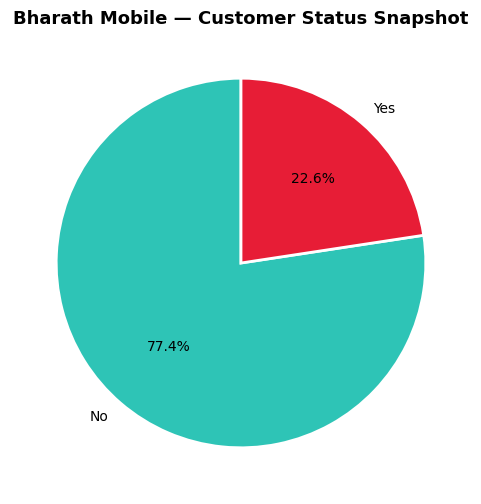

In [4]:
# Visualise the headline
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["Churned"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%",
       colors=["#2EC4B6", "#E71D36"], startangle=90,
       wedgeprops=dict(edgecolor="white", linewidth=2))
ax.set_title("Bharath Mobile — Customer Status Snapshot",
             fontsize=13, fontweight="bold")
plt.show()

**📝 Finding:** Roughly **22%** of the customer base has churned. For a benchmark, healthy Indian telecom monthly churn sits around 1.5–2%; the snapshot here reflects accumulated churn — still meaningful and worth attacking.

## 🔹 Question 2 — How are churners *different* from loyal customers?

For every numeric variable, compare the average for churners vs retained customers.

In [5]:
numeric_cols = ["Tenure_months", "MonthlyCharge", "TotalSpend",
                "DataUsage_GB", "ServiceCalls"]
profile = df.groupby("Churned")[numeric_cols].mean().round(2).T
profile["Difference"]    = (profile["Yes"] - profile["No"]).round(2)
profile["Diff_%"]        = (profile["Difference"] / profile["No"] * 100).round(1)
print(profile)

Churned              No       Yes  Difference  Diff_%
Tenure_months     29.81     24.28       -5.53   -18.6
MonthlyCharge    512.28    464.25      -48.03    -9.4
TotalSpend     15482.75  11139.92    -4342.83   -28.0
DataUsage_GB      40.02     37.11       -2.91    -7.3
ServiceCalls       1.68      2.50        0.82    48.8


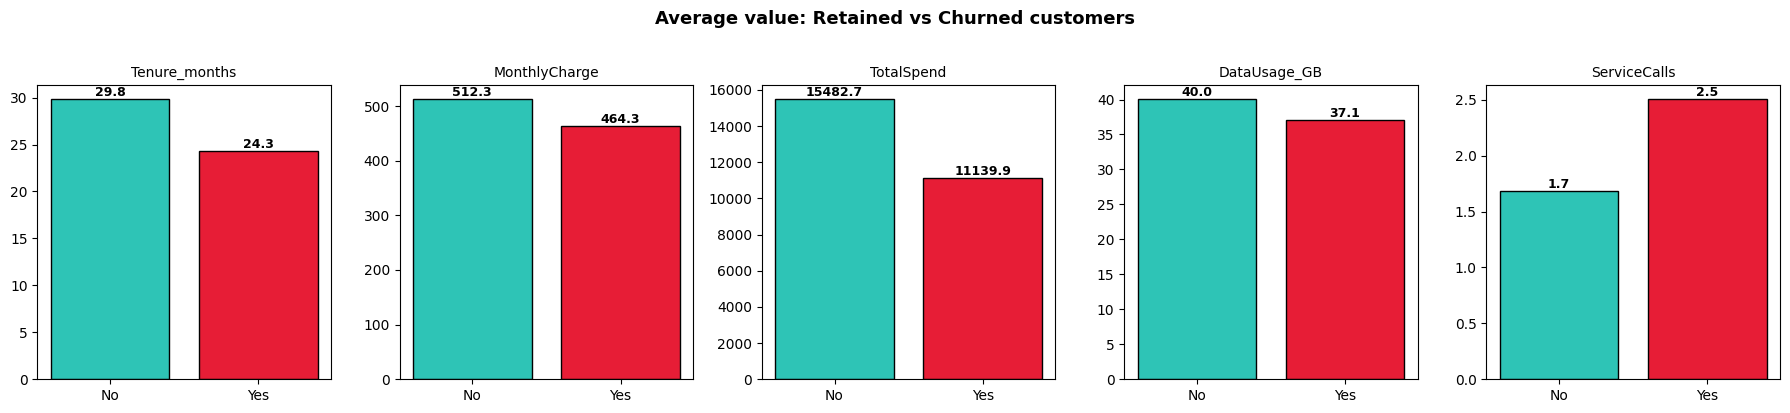

In [6]:
# Visualise the gap on each variable
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(numeric_cols):
    means = df.groupby("Churned")[col].mean()
    colors = ["#2EC4B6", "#E71D36"]
    axes[i].bar(means.index, means.values, color=colors, edgecolor="black")
    axes[i].set_title(col, fontsize=10)
    for j, v in enumerate(means.values):
        axes[i].text(j, v, f"{v:.1f}", ha="center", va="bottom",
                     fontsize=9, fontweight="bold")
fig.suptitle("Average value: Retained vs Churned customers",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**📝 Finding:** The most striking gaps:
- **Tenure** is much lower among churners — they leave before they're locked in
- **Service calls** are higher — every extra support call is a warning sign
- **Data usage** is lower — light users get less value, easier to leave

`MonthlyCharge` and `TotalSpend` are not strong differentiators on their own.

## 🔹 Question 3 — Which plan & payment behaviour predicts churn?

In [7]:
def churn_rate_by(group):
    return (df.groupby(group)["Churned"].apply(lambda s: (s == "Yes").mean() * 100)
              .round(1)
              .sort_values(ascending=False))

plan_churn    = churn_rate_by("Plan")
autopay_churn = churn_rate_by("AutoPay")

print("Churn rate by Plan:")
print(plan_churn.astype(str) + " %")
print("\nChurn rate by AutoPay:")
print(autopay_churn.astype(str) + " %")

Churn rate by Plan:
Plan
Basic       31.5 %
Family      21.4 %
Premium     19.1 %
Standard    17.5 %
Name: Churned, dtype: object

Churn rate by AutoPay:
AutoPay
No     31.4 %
Yes    16.2 %
Name: Churned, dtype: object


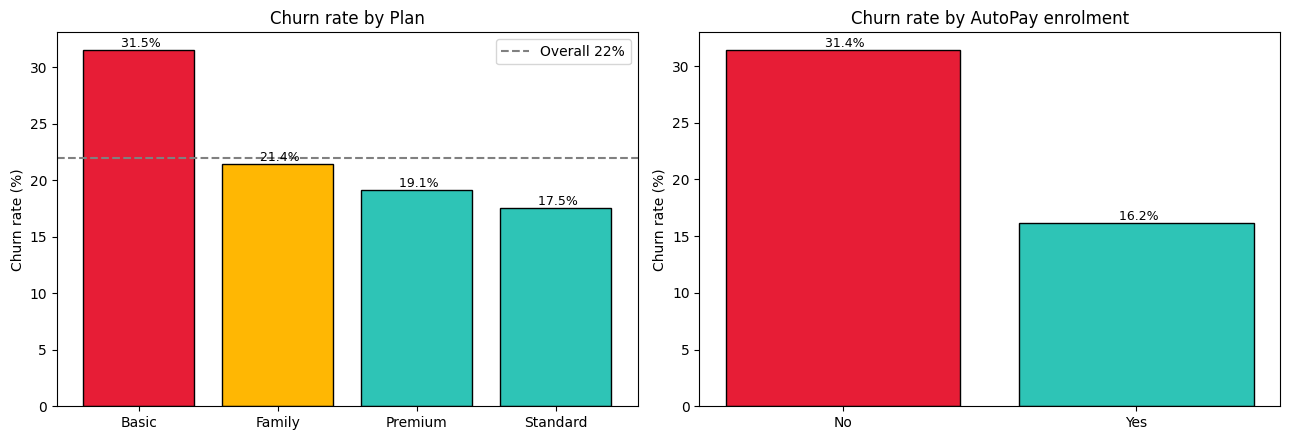

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(plan_churn.index, plan_churn.values,
            color=["#E71D36" if v > 25 else "#FFB703" if v > 20 else "#2EC4B6"
                   for v in plan_churn.values],
            edgecolor="black")
axes[0].axhline(22, color="grey", linestyle="--",
                label="Overall 22%")
axes[0].set_title("Churn rate by Plan")
axes[0].set_ylabel("Churn rate (%)")
axes[0].legend()
for i, v in enumerate(plan_churn.values):
    axes[0].text(i, v, f" {v}%", ha="center", va="bottom", fontsize=9)

axes[1].bar(autopay_churn.index, autopay_churn.values,
            color=["#E71D36", "#2EC4B6"], edgecolor="black")
axes[1].set_title("Churn rate by AutoPay enrolment")
axes[1].set_ylabel("Churn rate (%)")
for i, v in enumerate(autopay_churn.values):
    axes[1].text(i, v, f" {v}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

**📝 Finding:** **Customers without AutoPay churn far more often** than those with AutoPay enabled. **Basic-plan** users also churn the most — they have the least to lose by switching.

## 🔹 Question 4 — Build a simple risk score

Combine the strongest signals into a single 0–5 score where each ✅ = +1 risk point:

| Risk factor | Threshold |
|-------------|-----------|
| Short tenure | < 6 months |
| Many service calls | ≥ 3 |
| Low data usage | < 5 GB |
| No AutoPay | `No` |
| Basic plan | `Basic` |

In [9]:
def risk_score(row):
    score = 0
    if row["Tenure_months"] < 6:    score += 1
    if row["ServiceCalls"] >= 3:    score += 1
    if row["DataUsage_GB"] < 5:     score += 1
    if row["AutoPay"] == "No":      score += 1
    if row["Plan"] == "Basic":      score += 1
    return score

df["RiskScore"] = df.apply(risk_score, axis=1)

risk_summary = (df.groupby("RiskScore")
                  .agg(customers=("CustomerID","count"),
                       churn_rate=("Churned",
                                   lambda s: round((s == "Yes").mean() * 100, 1)))
                  .reset_index())
print(risk_summary)

   RiskScore  customers  churn_rate
0          0        120         5.0
1          1        207        17.9
2          2        129        35.7
3          3         39        51.3
4          4          5        80.0


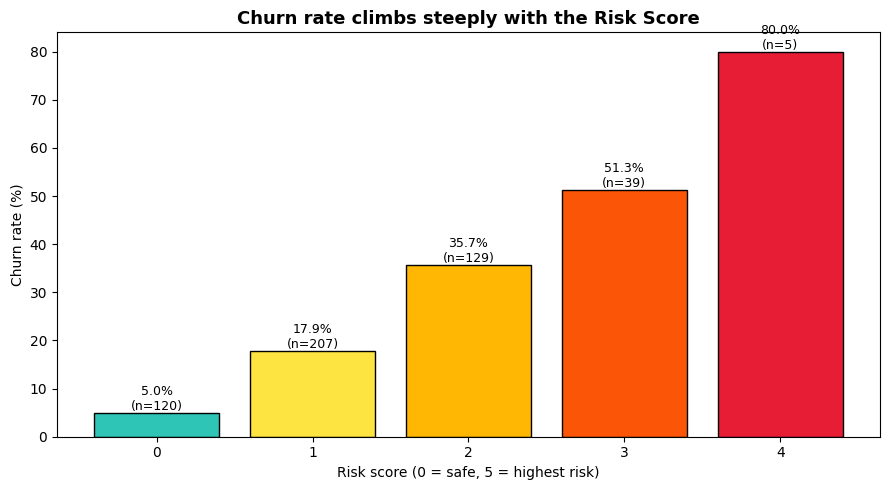

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2EC4B6", "#FEE440", "#FFB703", "#FB5607", "#E71D36", "#9B0000"]
bars = ax.bar(risk_summary["RiskScore"], risk_summary["churn_rate"],
              color=[colors[s] for s in risk_summary["RiskScore"]],
              edgecolor="black")
ax.set_title("Churn rate climbs steeply with the Risk Score",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Risk score (0 = safe, 5 = highest risk)")
ax.set_ylabel("Churn rate (%)")
for b, n, r in zip(bars, risk_summary["customers"],
                   risk_summary["churn_rate"]):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.6,
            f"{r}%\n(n={n})", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**📝 Finding:** Customers scoring ≥3 churn at multiples of the average rate. Score thresholds become a clear tier system: **0–1 = safe, 2 = monitor, 3+ = call this week.**

## 🔹 Question 5 — Top 100 at-risk active customers (the call list)

Of customers still active, prioritise by risk score and then by lifetime spend (we don't want to lose the high-value ones first).

In [11]:
active = df[df["Churned"] == "No"].copy()
call_list = (active.sort_values(["RiskScore", "TotalSpend"],
                                 ascending=[False, False])
                   .head(100)
                   .reset_index(drop=True))

print(f"Total active customers      : {len(active)}")
print(f"Active customers with risk≥3: {(active['RiskScore'] >= 3).sum()}")
print(f"\nFirst 10 of the call list:")
print(call_list.head(10)[["CustomerID","Tenure_months","Plan","TotalSpend",
                          "ServiceCalls","AutoPay","RiskScore"]])

# Save it for the call team
call_list.to_csv("case2_call_list.csv", index=False)
print("\n✅ Full 100-customer list saved as case2_call_list.csv")

Total active customers      : 387
Active customers with risk≥3: 20

First 10 of the call list:
  CustomerID  Tenure_months     Plan  TotalSpend  ServiceCalls AutoPay  \
0   BMC00275             53    Basic    10987.93             7      No   
1   BMC00032             57  Premium    39395.48             5      No   
2   BMC00344             88    Basic    17450.39             3      No   
3   BMC00354             56    Basic    11381.30             3      No   
4   BMC00447             48    Basic    10133.78             3      No   
5   BMC00073             51    Basic     9628.96             7     Yes   
6   BMC00242             31    Basic     6875.26             3      No   
7   BMC00439             29    Basic     5319.11             4      No   
8   BMC00109             23    Basic     4813.78             3     Yes   
9   BMC00186             18    Basic     3326.37             5      No   

   RiskScore  
0          4  
1          3  
2          3  
3          3  
4          3  


## 📋 Recommendations to Ms. Latha Krishnan

### 1️⃣ This week — call the 100 highest-risk customers
**Finding:** Active customers with RiskScore ≥3 churn at significantly higher rates than the base.
**Action:** Hand the saved `case2_call_list.csv` to the retention team. Offer each customer:
- A free month of data top-up (low cost, high perceived value), and
- A nudge to enrol in AutoPay with a 5% bill discount.

**Expected impact:** Even a 25% save rate on these 100 customers preserves ~25 customers at an average lifetime spend that pays for the entire campaign many times over.

### 2️⃣ Strategic — make AutoPay the default
**Finding:** Non-AutoPay customers churn at roughly 1.5–2× the AutoPay rate.
**Action:** Make AutoPay opt-out instead of opt-in for new customers, and run a one-time amnesty window for existing customers (5% bill discount for the first 3 months after enrolling).
**Expected impact:** Could shave 3–5 points off churn rate within two billing cycles.

### Bonus — fix the support experience
The data shows churners average noticeably more service calls than retained customers. Investigate the **top 5 reason codes** for support calls — fixing those will reduce churn upstream of the retention call.

---

## ✏️ Practice extensions

- Add a **probabilistic** churn model with `sklearn.linear_model.LogisticRegression`
- Test the score on a **hold-out sample** by splitting the dataset 80/20
- Compute **lifetime value** for each segment (`MonthlyCharge × expected remaining tenure`)
- Cluster customers with `sklearn.cluster.KMeans` and compare against the risk tiers